> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API and this case's dependencies
%pip install -q coptpy matplotlib numpy


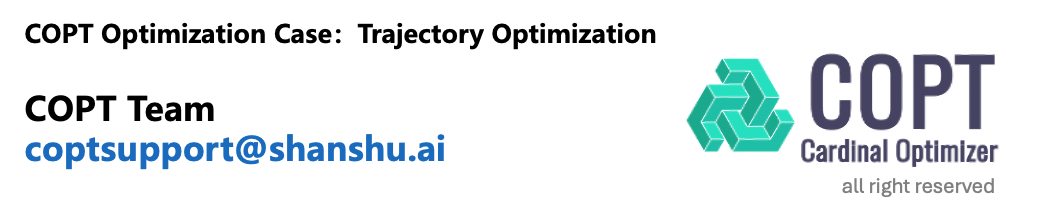

# Trajectory Optimization Code Implementation

## Steps to Model and Solve Trajectory Optimization Using COPT

1. Import the COPT-Python interface library `coptpy`

2. Add/Import the **model data**

3. Create the **COPT solving environment** and **COPT optimization model**

4. Build the model by sequentially adding the **three core components**
- **Decision variables**: Matrix variables `MVar` can be efficiently added using the matrix modeling approach.
- **Objective function**: Construct the matrix \$\boldsymbol{Q}\$ and add the standard quadratic term \$\mathbf{p}^{\top} \boldsymbol{Q} \mathbf{p}\$
- **Constraints**: Construct the matrix \$\boldsymbol{A}\$ and vector \$\mathbf{b}\$, and add the linear constraints. After discretizing the time and obstacle region, add **Indicator** constraints.


5. **Solve** the model

6. View and analyze the **results**

## Import COPT-Python API

In [5]:
import coptpy as cp
from coptpy import COPT
import numpy as np
import math
from math import factorial

## Add Model Data
In this case, we select a **9th-order polynomial** as the motion trajectory equation and minimize the **jerk energy** as the optimization objective to determine a set of optimal coefficients that satisfy the boundary conditions. A 9th-order polynomial has 10 coefficients to optimize, resulting in 10 variables. With 6 linearly independent motion conditions, the degrees of freedom are $10 - 6 = 4$. When dealing with practical problems, it is necessary to choose a suitable polynomial order for trajectory optimization, ensuring that the degrees of freedom $\geq 1$. When the degrees of freedom are $0$, the polynomial coefficients have a unique solution with no room for optimization.

For the system’s motion time $T$ and final position $x=a$, we set $T = 3.0\ s$ and $a = 5.0\ m$.

In [7]:
# Parameter Settings
T = 3.0 # unit: s
a = 5.0 # unit: m
n = 9  # order of the trajectory polynomial
r = 3  # jerk energy calculation requires the 3rd derivative

## Create the COPT Environment and COPT Model
Create a model named `trajectory_opt_1` as `model_1`.

In [9]:
env = cp.Envr()
model_1 = env.createModel("trajectory_opt_1")

Cardinal Optimizer v7.2.11. Build date Aug  1 2025
Copyright Cardinal Operations 2025. All Rights Reserved



## Add three core components of COPT Model

### Add Decision Variables
Add the decision variable $\mathbf{p}$, where $p_i \in [-10,\ 10],\ i = 0,\ 1,\ \dots,\ n$, which is a vector (matrix variable) of length 9.

In [11]:
# Add variables p0, p1, ..., p9 as a one-dimensional matrix variable.
p = model_1.addMVar(shape=n+1, lb=-10, ub=10, nameprefix="p")

### Set Objective Function
The objective function is
$$
\min_{\mathbf{p}}\; \ \mathbf{p}^{\top} \boldsymbol{Q} \mathbf{p}
$$
where $\boldsymbol{Q}$ is the matrix constructed when minimizing the jerk energy of the trajectory polynomial.
$$
\boldsymbol{Q} =
\int_{0}^{1} \boldsymbol{\phi}^{(3)}(t^*)\boldsymbol{\phi}^{(3)}(t^*)^{\top} \, dt^* =
\begin{bmatrix}
0 & 0 & 0 & 0 & 0 &  & \dots &  & 0 \\
0 & 0 & 0 & 0 & 0 &  & \dots &  & 0 \\
0 & 0 & 0 & 0 & 0 &  & \dots &  & 0 \\
0 & 0 & 0 & 36 & 72 & & \dots & & 6n(n-1) \\
0 & 0 & 0 & 72 & 192 & & \dots & & 24n(n-2) \\
& \vdots & & \vdots & \vdots & & \dots & & \vdots \\
0 & 0 & 0 & 6n(n-1) & 24n(n-2) & & \dots & & \frac{n^2(n-1)^2(n-2)^2}{(2n-5)}\\
\end{bmatrix}
$$

In [13]:
# Utility function for constructing matrix Q
def construct_Q(n: int, r: int) -> np.ndarray:
    """
    Formula for matrix elements i,j ∈ {0,...,n}:
        If i < r or j < r, then Q[i,j] = 0
        If i >= r and j >= r, then
            Q[i,j] = (i!/(i-r)!) * (j!/(j-r)!) / (i + j - 2r + 1)
    input:
    n : polynomial order (n >= 0)
    r : derivative order (0 <= r <= n)
    return:
    Q : (n+1)×(n+1) symmetric positive semidefinite matrix (numpy.ndarray)
    """
    if r < 0 or r > n:
        raise ValueError("Derivative order r must satisfy 0 <= r <= n")

    Q = np.zeros((n + 1, n + 1), dtype=float)

    # Precompute factorial and falling factorial coefficients c[i] = i! / (i-r)!
    fact = [factorial(k) for k in range(n + 1)]
    c = np.zeros(n + 1, dtype=float)
    for i in range(r, n + 1):
        c[i] = fact[i] / fact[i - r]

    # Fill matrix elements
    for i in range(r, n + 1):
        for j in range(r, n + 1):
            Q[i, j] = c[i] * c[j] / (i + j - 2 * r + 1)

    return Q

We construct the matrix $\boldsymbol{Q}$ in the quadratic objective function using the above function, and formulate the expression $\mathbf{p}^{\top} \boldsymbol{Q} \mathbf{p}$ via the matrix modeling approach:

In [15]:
# Add the objective function to minimize the jerk energy of the 9th-order polynomial
Q = construct_Q(n, r)
model_1.setObjective(p @ Q @ p, sense=COPT.MINIMIZE)

### Adding Constraints
The initial and terminal requirements for position, velocity, and acceleration are consolidated into linear constraints, represented in the matrix form:

$$
\text{s.t.}\;
\begin{cases}
x^*(0) = 0,\ x^*(1) = 1 \quad (\text{normalized position}) \\
x^{*(1)}(0) = 0,\ x^{*(1)}(1) = 0 \quad (\text{normalized velocity}) \\
x^{*(2)}(0) = 0,\ x^{*(2)}(1) = 0 \quad (\text{normalized acceleration})
\end{cases}
\quad \Longleftrightarrow \quad
\text{s.t.}\; \boldsymbol{A} \mathbf{p} = \mathbf{b}
$$

where
$$
\boldsymbol{A} =
\begin{bmatrix}
\boldsymbol{\phi}(0)^{\top} \\
\boldsymbol{\phi}^{(1)}(0)^{\top} \\
\boldsymbol{\phi}^{(2)}(0)^{\top} \\
\boldsymbol{\phi}(1)^{\top} \\
\boldsymbol{\phi}^{(1)}(1)^{\top} \\
\boldsymbol{\phi}^{(2)}(1)^{\top}
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & 0 & \dots & 0 \\
0 & 1 & 0 & \dots & 0 \\
0 & 0 & 2 & \dots & 0 \\
1 & 1 & 1 & \dots & 1 \\
0 & 1 & 2 & \dots & n \\
0 & 0 & 2 & \dots & n(n-1) \\
\end{bmatrix}
\quad \quad \quad
\mathbf{b} =
\begin{bmatrix}
0 \\
0 \\
0 \\
1 \\
0 \\
0
\end{bmatrix}
$$

In [17]:
# Compute the r-th derivative of the n-th order polynomial basis vector Φ(t*) at t*
def phi_derivative_value(n: int, r: int, t) -> np.ndarray:
    """
    Compute the r-th derivative of the n-th order polynomial basis
    φ(t*) = [1, t*, t*^2, ..., t*^n]^T
    at time t*, i.e., φ^{(r)}(t*).

    Formula for vector elements i ∈ {0,...,n}:
        i < r:        φ^{(r)}_i(t*) = 0
        i >= r:       φ^{(r)}_i(t*) = i!/(i-r)! * t*^{i-r}

    input
    -----
    n   : polynomial order (n >= 0)
    r   : derivative order (0 <= r <= n)
    t  : time, can be a scalar or a 1D numpy array

    return
    ------
    If t is a scalar, returns a vector of shape (n+1,);
    If t is an array, returns a matrix of shape (len(t), n+1)
    (each row corresponds to one t_k).
    """
    if r < 0 or r > n:
        raise ValueError("r must satisfy 0 <= r <= n")

    t_arr = np.asarray(t, dtype=float)
    scalar_input = (t_arr.ndim == 0)
    if scalar_input:
        t_arr = t_arr.reshape(1)

    m = t_arr.size
    out = np.zeros((m, n + 1), dtype=float)

    # Precompute falling factorial coefficients c[i] = i!/(i-r)!
    fact = [factorial(k) for k in range(n + 1)]
    c = np.zeros(n + 1, dtype=float)
    for i in range(r, n + 1):
        c[i] = fact[i] / fact[i - r]

    # Fill φ^{(r)}(t*) components
    for i in range(r, n + 1):
        out[:, i] = c[i] * (t_arr ** (i - r))

    return out[0] if scalar_input else out


# Construct matrix A and vector b
A = np.array([
    phi_derivative_value(n, 0, 0),
    phi_derivative_value(n, 1, 0),
    phi_derivative_value(n, 2, 0),
    phi_derivative_value(n, 0, 1),
    phi_derivative_value(n, 1, 1),
    phi_derivative_value(n, 2, 1),
], dtype=float)

b = np.array([0, 0, 0, 1, 0, 0], dtype=float)

# Add constraints
# model_1.addMConstr(A=A, x=p, sense=COPT.EQUAL, b=b, nameprefix="")
model_1.addConstrs(A@p == b, nameprefix="")

MConstr(shape=(6,), data=
[<coptpy.Constraint: (0)> <coptpy.Constraint: (1)>
 <coptpy.Constraint: (2)> <coptpy.Constraint: (3)>
 <coptpy.Constraint: (4)> <coptpy.Constraint: (5)>])

## Solve

In [19]:
model_1.solve()

Model fingerprint: afaae091

Using Cardinal Optimizer v7.2.11 on macOS (aarch64)
Hardware has 10 cores and 10 threads. Using instruction set ARMV8 (30)
Minimizing a QP problem

The original problem has:
    6 rows, 10 columns and 30 non-zero elements
    28 quadratic objective elements
The presolved problem has:
    10 rows, 14 columns and 56 non-zero elements
    7 quadratic objective elements

Starting barrier solver using 10 CPU threads

Problem info:
Dualized in presolve:            No
Range of matrix coefficients:    [2e-01,9e+01]
Range of rhs coefficients:       [1e+00,1e+00]
Range of bound coefficients:     [1e+01,1e+01]
Range of cost coefficients:      [0e+00,0e+00]
Range of quadcost coefficients:  [1e+00,1e+00]

Factor info:
Number of free columns:          7
Number of dense columns:         0
Number of matrix entries:        5.500e+01
Number of factor entries:        5.500e+01
Number of factor flops:          3.850e+02

Iter       Primal.Obj         Dual.Obj      Compl  Prima

## Retrieve Results

After solving the optimal solution, we can derive the minimum jerk energy value and the corresponding parameters of the optimal smooth trajectory equation.

In [21]:
# Output results
if model_1.status == COPT.OPTIMAL:
    print("Optimal jerk(non-dimension):", model_1.objval)
    print("Coefficients:")
    p_results = np.array(p.X.tolist())    # matplotlib cannot consume coptpy's NdArray
    for i, item in enumerate(p_results):
        print(" p({0}) = {1:.3f}".format(i, item))
else:
    print("Solve failed with status:", model_1.status)

Optimal jerk(non-dimension): 721.316347526782
Coefficients:
 p(0) = 0.000
 p(1) = 0.000
 p(2) = 0.000
 p(3) = 9.072
 p(4) = -10.000
 p(5) = -4.435
 p(6) = 10.000
 p(7) = -3.465
 p(8) = -0.761
 p(9) = 0.589


Furthermore, we can obtain the position, velocity, and acceleration of the motion trajectory at each time step, along with their corresponding physical dimensions, and plot the trajectory curves.

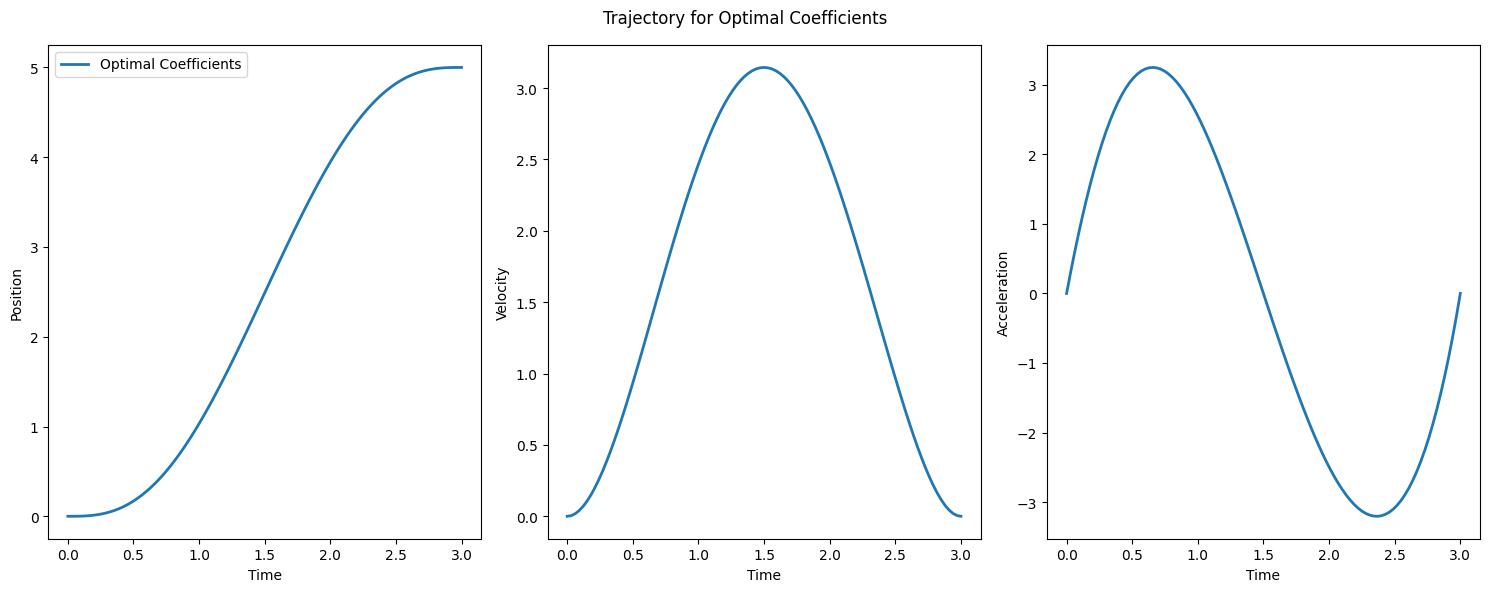

In [23]:
# Compute position, velocity, and acceleration at each time step
time_grid_star = np.linspace(0.0, 1.0, 100+1)
position_1D_star = phi_derivative_value(n, 0, time_grid_star) @ p_results
velocity_1D_star = phi_derivative_value(n, 1, time_grid_star) @ p_results
acceleration_1D_star = phi_derivative_value(n, 2, time_grid_star) @ p_results

# Restore physical dimensions
time_grid = time_grid_star * T
position_1D = a * position_1D_star
velocity_1D = (a / T) * velocity_1D_star
acceleration_1D = (a / T**2) * acceleration_1D_star


# Plot trajectory
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.subplot(1, 3, 1)
plt.plot(time_grid, position_1D, linewidth=2, label="Optimal Coefficients")
plt.xlabel("Time")
plt.ylabel("Position")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(time_grid, velocity_1D, linewidth=2, label="Optimal Coefficients")
plt.xlabel("Time")
plt.ylabel("Velocity")

plt.subplot(1, 3, 3)
plt.plot(time_grid, acceleration_1D, linewidth=2, label="Optimal Coefficients")
plt.xlabel("Time")
plt.ylabel("Acceleration")

plt.suptitle("Trajectory for Optimal Coefficients")
plt.tight_layout()
plt.show()

# Case Expansion: Two-dimensional Trajectories with Obstacle Avoidance

## Add Model Data

In [26]:
n = 9   # order of the trajectory polynomial
r = 3   # jerk energy calculation requires the 3rd derivative
T = 2.0 # unit: s

x_obs = np.array([1.0, 0.8])  # obstacle position
R_safe = 0.3                  # safe distance

# Initial state
x_0 = np.array([0.0, 0.0])
v_0 = np.array([1.0, 1.0])
a_0 = np.array([0.0, 0.0])

# Terminal state
x_T = np.array([2.0, 1.5])
v_T = np.array([0.0, 0.0])
a_T = np.array([0.0, 0.0])

# Discretization parameters
K = 40  # number of time intervals
L = 20  # number of discretized direction angles

### Data Normalization

In [28]:
# Obstacle center (normalized)
x_obs_star = (x_obs - x_0) / (x_T - x_0)

# Normalized ellipse radii: R*_x, R*_y
R_star = R_safe / (x_T - x_0)

# Discretized time and angle
t_star = {k: k / K for k in range(K + 1)}   # normalized time
theta  = {l: 2 * np.pi * l / L for l in range(1, L + 1)}  # direction angles

# Unit normal vectors
n_hat = {l: np.array([np.cos(theta[l]), np.sin(theta[l])], dtype=float)
         for l in range(1, L + 1)}

# Intercepts
d_star = {l: n_hat[l] @ x_obs_star + np.linalg.norm(R_star * n_hat[l])
          for l in range(1, L + 1)}

# Initial and terminal states (normalized)
x_0_star = (x_0 - x_0) / (x_T - x_0)
v_0_star = T / (x_T - x_0) * v_0
a_0_star = T**2 / (x_T - x_0) * a_0

x_T_star = (x_T - x_0) / (x_T - x_0)
v_T_star = T / (x_T - x_0) * v_T
a_T_star = T**2 / (x_T - x_0) * a_T

## Create the COPT Environment and COPT Model
Create a model named `trajectory_opt_2` as `model_2`.

In [30]:
env = cp.Envr()
model_2 = env.createModel("trajectory_opt_2")

Cardinal Optimizer v7.2.11. Build date Aug  1 2025
Copyright Cardinal Operations 2025. All Rights Reserved



## Add three core components of COPT Model

### Add Decision Variables
Add decision variables $\mathbf{p}_x$ and $\mathbf{p}_y$, where the value range of all elements is $[-10,\ 10]$. Add binary variables $b_{k,\ell}$.

In [32]:
p_x = model_2.addMVar(shape=n+1, lb=-10, ub=10, nameprefix="p_x")
p_y = model_2.addMVar(shape=n+1, lb=-10, ub=10, nameprefix="p_y")
b_index = list((k, l) for k in range(K+1) for l in range(1, L+1))
b = model_2.addVars(b_index, vtype=COPT.BINARY, nameprefix="b")

### Set Objective Function
The objective function is
$$
\min_{\mathbf{p}_x,\ \mathbf{p}_y}\quad \mathbf{p}^{\top}_{x} \boldsymbol{Q} \mathbf{p}_{x} + \mathbf{p}^{\top}_{y} \boldsymbol{Q} \mathbf{p}_{y}
$$

In [34]:
Q = construct_Q(n, r)
model_2.setObjective(p_x @ Q @ p_x + p_y @ Q @ p_y, sense=COPT.MINIMIZE)

### Add Constraints
Add linear constraints for the initial and terminal states.
$$
\boldsymbol{A} \mathbf{p}_x = \mathbf{b}_x
$$
$$
\boldsymbol{A} \mathbf{p}_y = \mathbf{b}_y
$$
$$
\mathbf{b}_x =
\begin{bmatrix}
x_0^* \\
v_{x,0}^* \\
a_{x,0}^* \\
x_T^* \\
v_{x,T}^* \\
a_{x,T}^*
\end{bmatrix}
\quad \quad \quad
\mathbf{b}_y =
\begin{bmatrix}
y_0^* \\
v_{y,0}^* \\
a_{y,0}^* \\
y_T^* \\
v_{y,T}^* \\
a_{y,T}^*
\end{bmatrix}
$$

In [36]:
b_x = np.array([x_0_star[0], v_0_star[0], a_0_star[0], x_T_star[0], v_T_star[0], a_T_star[0]])
b_y = np.array([x_0_star[1], v_0_star[1], a_0_star[1], x_T_star[1], v_T_star[1], a_T_star[1]])

model_2.addMConstr(A=A, x=p_x, sense=COPT.EQUAL, b=b_x, nameprefix="x-direction-linear-constraint")
model_2.addMConstr(A=A, x=p_y, sense=COPT.EQUAL, b=b_y, nameprefix="y-direction-linear-constraint")

MConstr(shape=(6,), data=
[<coptpy.Constraint: y-direction-linear-constraint(0)>
 <coptpy.Constraint: y-direction-linear-constraint(1)>
 <coptpy.Constraint: y-direction-linear-constraint(2)>
 <coptpy.Constraint: y-direction-linear-constraint(3)>
 <coptpy.Constraint: y-direction-linear-constraint(4)>
 <coptpy.Constraint: y-direction-linear-constraint(5)>])

Add obstacle avoidance constraints.
$$
\begin{aligned}
\sum_{\ell = 1}^{L}\ b_{k,\ell} &\geq 1,\quad\quad\quad k = 0,\ 1,\ \cdots,K \\
\hat{\mathbf{n}}_{\ell}^{\top}\,\begin{bmatrix}
\boldsymbol{\phi}(t_k^*)^{\top} \mathbf{p}_x \\
\boldsymbol{\phi}(t_k^*)^{\top} \mathbf{p}_y \\
\end{bmatrix} &\geq d_{\ell}^*,\quad\quad\quad if \ \  b_{k,\ell} = 1
\end{aligned}
$$

<font color=#0000FF>
<b>Hint: Using COPT to Add Indicator Constraints</b>
</font>

Indicator constraints are a type of *If–Then* logical relationship constraint: a binary variable $y$ serves as the indicator, and depending on the value of $y$, it determines whether the linear constraint becomes active:

$$
y = 1 \;\Rightarrow\; a^{\top}x \leq b
$$
$$
y \in \{0,\ 1\}
$$

Meaning: if $y=1$, then the linear constraint $a^{\top}x \leq b$ holds.

For *If–Then* conditional constraints, you can use **COPT**’s Indicator constructor
`Model.addGenConstrIndicator(binvar, binval, lhs, sense=None, rhs=None, type=COPT.INDICATOR_IF, name="")` to add them. The following parameters need to be specified:

- `binVar`: binary variable, serving as the indicator;
- `binval`: the value of the indicator, which can be `True` or `False`, representing the binary variable taking the value $1$ or $0$;
- `lhs`: the linear constraint expression that must hold when `binVar` is `True`.

In [39]:
for k in range(K+1):
    for l in range(1, L+1):
        phi_k = np.array(phi_derivative_value(n, 0, t_star[k]))
        x_k = phi_k @ p_x
        y_k = phi_k @ p_y
        expr = n_hat[l][0] * x_k + n_hat[l][1] * y_k
        model_2.addGenConstrIndicator(b[(k, l)], True, expr >= d_star[l])
    model_2.addConstr(cp.quicksum(b[(k, l)] for l in range(1, L+1)) >= 1)

## Solve

In [41]:
model_2.solve()

Model fingerprint: ad74e69f

Using Cardinal Optimizer v7.2.11 on macOS (aarch64)
Hardware has 10 cores and 10 threads. Using instruction set ARMV8 (30)
Minimizing a MIQP problem

The original problem has:
    53 rows, 840 columns and 880 non-zero elements
    820 binaries
    820 indicators
    56 quadratic objective elements

Starting the MIP solver with 10 threads and 32 tasks

Presolving the problem

The presolved problem has:
    488 rows, 479 columns and 4232 non-zero elements
    8 SOC rows and 24 non-zero elements
    451 binaries


     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  2.933333e+02            --     Inf  0.11s
         0         1      --      24  2.933333e+02            --     Inf  0.17s
         0         1      --      26  2.933333e+02            --     Inf  0.18s
         0         1      --      26  2.933333e+02            --     Inf  0.18s
         0         1      --      26  2.933333e+02    

## Retrieve Results

In [43]:
if model_2.status == COPT.OPTIMAL:
    print("Optimal jerk(non-dimension):", model_2.objval)
    print("Coefficients:")
    px_results = np.array(p_x.X.tolist())
    py_results = np.array(p_y.X.tolist())
    for i, item in enumerate(px_results):
        print(" p_x({0}) = {1:.3f}".format(i, item))
    for i, item in enumerate(py_results):
        print(" p_y({0}) = {1:.3f}".format(i, item))
else:
    print("Solve failed with status:", model_2.status)

Optimal jerk(non-dimension): 965.5193568943433
Coefficients:
 p_x(0) = 0.000
 p_x(1) = 1.000
 p_x(2) = 0.000
 p_x(3) = -3.704
 p_x(4) = 10.000
 p_x(5) = -0.763
 p_x(6) = -10.000
 p_x(7) = -1.862
 p_x(8) = 10.000
 p_x(9) = -3.671
 p_y(0) = 0.000
 p_y(1) = 1.333
 p_y(2) = 0.000
 p_y(3) = 5.601
 p_y(4) = -10.000
 p_y(5) = -3.178
 p_y(6) = 10.000
 p_y(7) = 3.720
 p_y(8) = -10.000
 p_y(9) = 3.524


Furthermore, we can obtain the position, velocity, and acceleration of the motion trajectory at each time step, along with their corresponding physical dimensions, and plot the trajectory curves with obstacle avoidance.

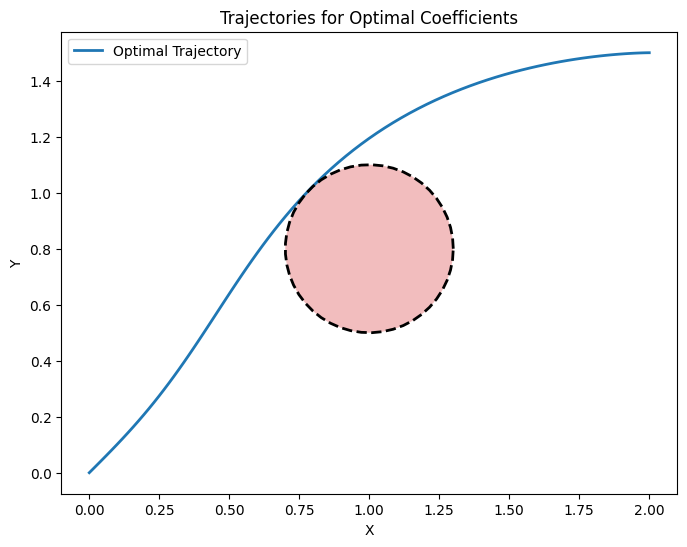

In [45]:
# Compute position, velocity, and acceleration at each time step
time_grid_star = np.linspace(0.0, 1.0, 100+1)
position_2D_x_star = phi_derivative_value(n, 0, time_grid_star) @ px_results
position_2D_y_star = phi_derivative_value(n, 0, time_grid_star) @ py_results

# Recover physical units
time_grid = time_grid_star * T
position_2D_x = position_2D_x_star * (x_T[0] - x_0[0]) + x_0[0]
position_2D_y = position_2D_y_star * (x_T[1] - x_0[1]) + x_0[1]

# Plot the impassable circular obstacle
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def plot_obstacle(ax, center, radius,
                  facecolor="tab:red", edgecolor="k", alpha=0.3,
                  linestyle="--", linewidth=2):
    """
    Plot a circular obstacle with boundary and shaded fill.

    input:
    - ax        : matplotlib Axes object
    - center    : (x, y) coordinates of the circle center
    - radius    : radius of the circle
    - facecolor : fill color
    - edgecolor : boundary color
    - alpha     : fill transparency
    - linestyle : boundary line style
    - linewidth : boundary line width
    """
    x_obs, y_obs = center
    # Shaded fill
    circ = Circle(center, radius, facecolor=facecolor,
                  edgecolor=edgecolor, alpha=alpha, linewidth=0)
    ax.add_patch(circ)

    # Boundary line
    theta = np.linspace(0, 2*np.pi, 50)
    ax.plot(x_obs + radius*np.cos(theta),
            y_obs + radius*np.sin(theta),
            color=edgecolor, linestyle=linestyle, linewidth=linewidth)

    return ax

# Plot trajectory
fig, ax = plt.subplots(figsize=(8, 6))
# Trajectory
ax.plot(position_2D_x, position_2D_y, linewidth=2, label="Optimal Trajectory")

# Add obstacle
plot_obstacle(ax, center=x_obs, radius=R_safe)

ax.set_aspect("equal", adjustable="box")
ax.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Trajectories for Optimal Coefficients")
plt.show()